In [ ]:
# Basic setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf


In [ ]:
url = "https://raw.githubusercontent.com/EshanUGR/DL-Assigment/refs/heads/main/data/BAJAJ-AUTO.csv"
df = pd.read_csv(url)
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJ-AUTO,EQ,2101.05,898.00,898.0,551.35,600.25,604.75,624.61,3972485,2.481245e+14,NaN,1202933,0.3028
1,2008-05-27,BAJAJ-AUTO,EQ,604.75,624.70,639.0,580.30,595.50,593.15,606.43,1751063,1.061901e+14,NaN,369389,0.2110
2,2008-05-28,BAJAJ-AUTO,EQ,593.15,561.65,621.9,561.65,605.10,608.15,608.75,1652355,1.005877e+14,NaN,898602,0.5438
3,2008-05-29,BAJAJ-AUTO,EQ,608.15,619.40,619.4,576.00,600.00,599.45,600.98,669269,4.022165e+13,NaN,449951,0.6723
4,2008-05-30,BAJAJ-AUTO,EQ,599.45,605.40,607.0,538.00,576.25,571.70,565.55,1262117,7.137937e+13,NaN,936432,0.7420


In [ ]:
# Keep only the relevant columns
df = df[['Date','Open','High','Low','Close','Volume']]

# Convert Date column and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Volume
0,2008-05-26,898.00,898.0,551.35,604.75,3972485
1,2008-05-27,624.70,639.0,580.30,593.15,1751063
2,2008-05-28,561.65,621.9,561.65,608.15,1652355
3,2008-05-29,619.40,619.4,576.00,599.45,669269
4,2008-05-30,605.40,607.0,538.00,571.70,1262117


In [ ]:
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna().reset_index(drop=True)

df.head()



,Date,Open,High,Low,Close,Volume,Next_Close
0,2008-05-26,898.00,898.0,551.35,604.75,3972485,593.15
1,2008-05-27,624.70,639.0,580.30,593.15,1751063,608.15
2,2008-05-28,561.65,621.9,561.65,608.15,1652355,599.45
3,2008-05-29,619.40,619.4,576.00,599.45,669269,571.70
4,2008-05-30,605.40,607.0,538.00,571.70,1262117,580.80


In [ ]:
X = df[['Open','High','Low','Close','Volume']].values
y = df['Next_Close'].values

In [ ]:
X[0:5]



array([[8.980000e+02, 8.980000e+02, 5.513500e+02, 6.047500e+02,
        3.972485e+06],
       [6.247000e+02, 6.390000e+02, 5.803000e+02, 5.931500e+02,
        1.751063e+06],
       [5.616500e+02, 6.219000e+02, 5.616500e+02, 6.081500e+02,
        1.652355e+06],
       [6.194000e+02, 6.194000e+02, 5.760000e+02, 5.994500e+02,
        6.692690e+05],
       [6.054000e+02, 6.070000e+02, 5.380000e+02, 5.717000e+02,
        1.262117e+06]])

In [ ]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
X_test.shape

(640, 5)

Normalize Features

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test  = scaler_y.transform(y_test.reshape(-1,1))


Build the ANN Model

In [ ]:
#Simple 3-layer network for regression:
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)  # regression output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0217 - mae: 0.1044 - val_loss: 0.0039 - val_mae: 0.0607 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - mae: 0.0373 - val_loss: 0.0045 - val_mae: 0.0649 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - mae: 0.0290 - val_loss: 0.0050 - val_mae: 0.0688 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - mae: 0.0257 - val_loss: 0.0054 - val_mae: 0.0718 - learning_rate: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0240 - val_loss: 0.0089 - val_mae: 0.0923 - learning_rate: 0.0010
Epoch 6/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.7911e-04 - mae: 0.0214
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.7629e-04 - mae: 0.0214 - val_loss: 0.0085 - val_mae: 0.0907 - learning_rate: 0.0010
Ep

Visualize Training Progress

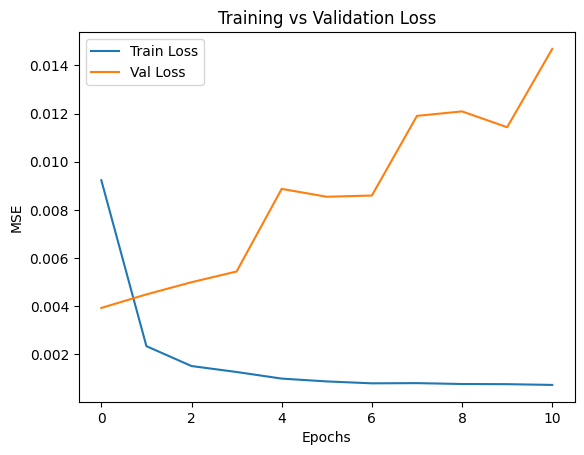

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.xlabel('Epochs'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.show()


Evaluate on Test Data

In [ ]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred))
r2   = r2_score(y_test_inv, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 203.10
R² Score: 0.7412


Plot Actual vs Predicted Close Price

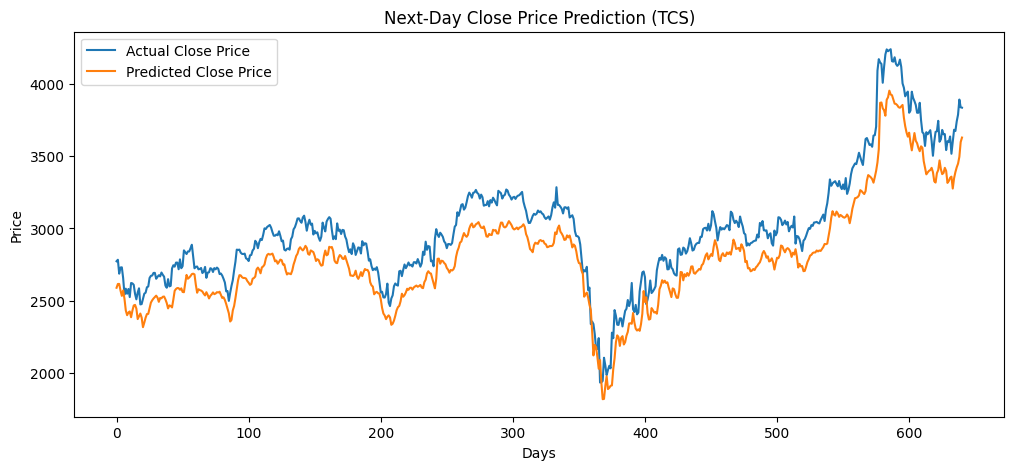

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual Close Price')
plt.plot(y_pred, label='Predicted Close Price')
plt.legend(); plt.title('Next-Day Close Price Prediction (TCS)')
plt.xlabel('Days'); plt.ylabel('Price')
plt.show()
